# 02 - Attention Access Test

This notebook verifies that the SUPERB wav2vec 2.0 emotion classifier used by Pastor et al. exposes its Transformer attention maps for one IEMOCAP utterance.

The next cell loads project paths, plotting tools, and the configured classifier checkpoint.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np

from speech_xai_project import audio, config, model

project_config = config.load_config(PROJECT_ROOT / 'configs' / 'default.yaml')
IEMOCAP_ROOT = config.project_path(project_config['paths']['iemocap_root'])
MODEL_SOURCE = project_config['model']['source']
MODEL_CACHE_DIR = config.project_path(project_config['model']['cache_dir'])
TARGET_SAMPLE_RATE = project_config['model']['sample_rate']
AUDIO_ID = 'Ses01F_impro01_F005'

The next cell finds the selected utterance and loads its mono waveform at 16 kHz.

In [2]:
audio_matches = list(IEMOCAP_ROOT.rglob(f'{AUDIO_ID}.wav'))
assert len(audio_matches) == 1, f'Expected one audio match, found {len(audio_matches)}.'
audio_path = audio_matches[0]
waveform, sample_rate = audio.load_waveform(audio_path, TARGET_SAMPLE_RATE)
print('Audio:', audio_path)
print('Waveform shape:', tuple(waveform.shape))
print('Duration:', round(audio.duration_seconds(waveform, sample_rate), 3), 'seconds')

Audio: C:\Users\mateu\repos\gradient_based_speach_xai\data\Session1\sentences\wav\Ses01F_impro01\Ses01F_impro01_F005.wav
Waveform shape: (1, 64479)
Duration: 4.03 seconds


The next cell loads the exact Hugging Face classifier used by SpeechXAI for IEMOCAP and shows its main module hierarchy.

In [3]:
classifier = model.load_classifier(MODEL_SOURCE, MODEL_CACHE_DIR)
print('Model source:', MODEL_SOURCE)
print('Labels:', classifier.network.config.id2label)
model.print_module_tree(classifier.network, max_depth=2)

C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Model source: superb/wav2vec2-base-superb-er
Labels: {0: 'neu', 1: 'hap', 2: 'ang', 3: 'sad'}
<root>: Wav2Vec2ForSequenceClassification
  wav2vec2: Wav2Vec2Model
    wav2vec2.feature_extractor: Wav2Vec2FeatureEncoder
    wav2vec2.feature_projection: Wav2Vec2FeatureProjection
    wav2vec2.encoder: Wav2Vec2Encoder
  projector: Linear
  classifier: Linear


The next cell requests attention outputs and validates the number, shape, and numerical range of the returned tensors.

In [4]:
model_inputs = model.prepare_model_inputs(classifier, waveform)
outputs = classifier.network(
    **model_inputs,
    output_attentions=True,
    output_hidden_states=True,
    return_dict=True,
)
attentions = outputs.attentions
probabilities = outputs.logits.softmax(dim=-1)[0].detach().cpu()
predicted_index = int(probabilities.argmax())

assert attentions is not None
assert len(attentions) == classifier.network.config.num_hidden_layers
assert all(attention.ndim == 4 for attention in attentions)
assert all(np.isfinite(attention.detach().cpu().numpy()).all() for attention in attentions)

print('Predicted emotion:', classifier.network.config.id2label[predicted_index])
print('Confidence:', round(float(probabilities[predicted_index]), 6))
print('Transformer layers:', len(attentions))
print('Attention heads:', attentions[0].shape[1])
print('Attention shape per layer:', tuple(attentions[0].shape))
first_attention = attentions[0].detach()
print('Layer 1 range:', float(first_attention.min()), 'to', float(first_attention.max()))

Predicted emotion: ang
Confidence: 0.878075
Transformer layers: 12
Attention heads: 12
Attention shape per layer: (1, 12, 201, 201)
Layer 1 range: 4.405696745379828e-05 to 0.29297158122062683


The next cell visualizes one attention head from the final Transformer layer.

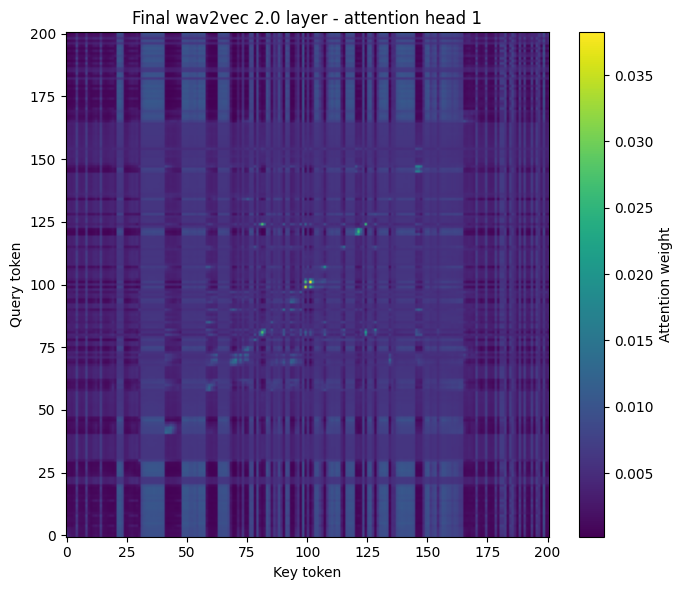

In [5]:
attention_matrix = attentions[-1][0, 0].detach().cpu().numpy()
figure, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(attention_matrix, origin='lower', aspect='auto', cmap='viridis')
axis.set_title('Final wav2vec 2.0 layer - attention head 1')
axis.set_xlabel('Key token')
axis.set_ylabel('Query token')
figure.colorbar(image, ax=axis, label='Attention weight')
figure.tight_layout()
plt.show()

Attention access succeeded when all assertions above pass. The classifier returns one `[batch, heads, tokens, tokens]` tensor for each Transformer layer. Notebook 03 can now test gradients of the predicted-class logit with respect to these tensors.